In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [82]:
df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (20000, 25)


In [83]:
print(df.columns.tolist())

['PatientID', 'Street', 'Location', 'Latitude', 'Longitude', 'Admission_Type', 'Discharge_Disposition', 'Admission_Date', 'Discharge_Date', 'Length_of_Stay', 'Age', 'Gender', 'Ethnicity', 'Primary_Diagnosis', 'Secondary_Diagnosis', 'Procedure_Code', 'Procedure_Description', 'Comorbidities', 'Medication', 'Follow_Up', 'Insurance', 'Notes', 'Doctor_Comments', 'Medication_Details', 'Admission_Category']


In [84]:
df.head()

,PatientID,Street,Location,Latitude,Longitude,Admission_Type,Discharge_Disposition,Admission_Date,Discharge_Date,Length_of_Stay,...,Procedure_Code,Procedure_Description,Comorbidities,Medication,Follow_Up,Insurance,Notes,Doctor_Comments,Medication_Details,Admission_Category
0,624c2f33-ddee-4cec-b3af-6b066c9460ac,NaN,Walterville,35.433998,-117.814557,Emergency,Transferred to another hospital,2022-10-31,2022-11-11,24,...,1171,Procedure A,No,Medication E,NaN,Uninsured,Building not including find defense even task ...,Camera full society example. Experience truth ...,Concern view administration take to so treatme...,Urgent
1,7d4fa4db-d71c-477c-b82a-1c6f87e4cc5c,2687 Christine Crescent Apt. 794,New Vanessaside,34.144074,-117.359235,Newborn,Left against medical advice,2023-05-14,2020-02-28,10,...,6408,Procedure D,No,Medication E,NaN,Medicaid,Per husband important now. Series job wear. Un...,Always remain station day. By significant brin...,Lose several high woman paper like. Leader lik...,Newborn
2,12a1fe7d-dfa5-4722-8a1f-c9df9a591974,089 Hahn Fort,East Bryceview,35.394841,-117.372186,Elective,Discharged to rehabilitation,2021-08-27,2021-02-26,11,...,2847,Procedure A,Yes,Medication E,No,Medicaid,Standard health share town safe head less. Doc...,Economy practice star machine heavy think. Ani...,Month source range several amount available. C...,Urgent
3,92abe1cb-7f1f-4b30-855f-9ac0a1a5366b,NaN,NaN,34.822082,-117.494405,Elective,Discharged to rehabilitation,2023-04-17,2024-05-02,19,...,9219,Procedure B,No,Medication D,NaN,Uninsured,NaN,Hand amount shoulder area particularly image s...,Guy worry travel lot. Across recently might ch...,Urgent
4,69fb0763-8a9c-46f7-8ee4-e5125802b640,12652 Aaron Centers,East Amber,34.545248,-117.210027,Urgent,Discharged to home,2023-02-15,2023-02-18,6,...,4751,Procedure A,No,Medication E,NaN,Private,Maintain arm new somebody. Form possible examp...,Career chair product even stage peace staff. B...,Key suggest pass. Hit follow class prove bit a...,Urgent


In [85]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

Rows: 20000
Columns: 25

Data Types:
PatientID                    str
Street                       str
Location                     str
Latitude                 float64
Longitude                float64
Admission_Type               str
Discharge_Disposition        str
Admission_Date               str
Discharge_Date               str
Length_of_Stay             int64
Age                        int64
Gender                       str
Ethnicity                    str
Primary_Diagnosis            str
Secondary_Diagnosis          str
Procedure_Code             int64
Procedure_Description        str
Comorbidities                str
Medication                   str
Follow_Up                    str
Insurance                    str
Notes                        str
Doctor_Comments              str
Medication_Details           str
Admission_Category           str
dtype: object


In [86]:
df.nunique().sort_values(ascending=False)

PatientID                20000
Medication_Details       20000
Doctor_Comments          20000
Latitude                 19896
Longitude                19790
Notes                    18000
Location                 12301
Procedure_Code            8010
Street                    8000
Admission_Date            1634
Discharge_Date            1634
Age                        100
Length_of_Stay              29
Primary_Diagnosis            5
Procedure_Description        5
Secondary_Diagnosis          5
Ethnicity                    5
Medication                   5
Discharge_Disposition        4
Admission_Type               4
Insurance                    4
Admission_Category           4
Gender                       3
Follow_Up                    2
Comorbidities                2
dtype: int64

In [87]:
df["Length_of_Stay"].value_counts().sort_index()

Length_of_Stay
1     699
2     706
3     648
4     677
5     731
6     691
7     683
8     720
9     673
10    711
11    727
12    686
13    688
14    701
15    697
16    703
17    641
18    687
19    699
20    695
21    697
22    666
23    693
24    671
25    653
26    689
27    676
28    692
29    700
Name: count, dtype: int64

In [88]:
categorical_cols = df.select_dtypes(include="object").columns
print(categorical_cols.tolist())

['PatientID', 'Street', 'Location', 'Admission_Type', 'Discharge_Disposition', 'Admission_Date', 'Discharge_Date', 'Gender', 'Ethnicity', 'Primary_Diagnosis', 'Secondary_Diagnosis', 'Procedure_Description', 'Comorbidities', 'Medication', 'Follow_Up', 'Insurance', 'Notes', 'Doctor_Comments', 'Medication_Details', 'Admission_Category']


C:\Users\horizon Traders\AppData\Local\Temp\ipykernel_12136\1130493559.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


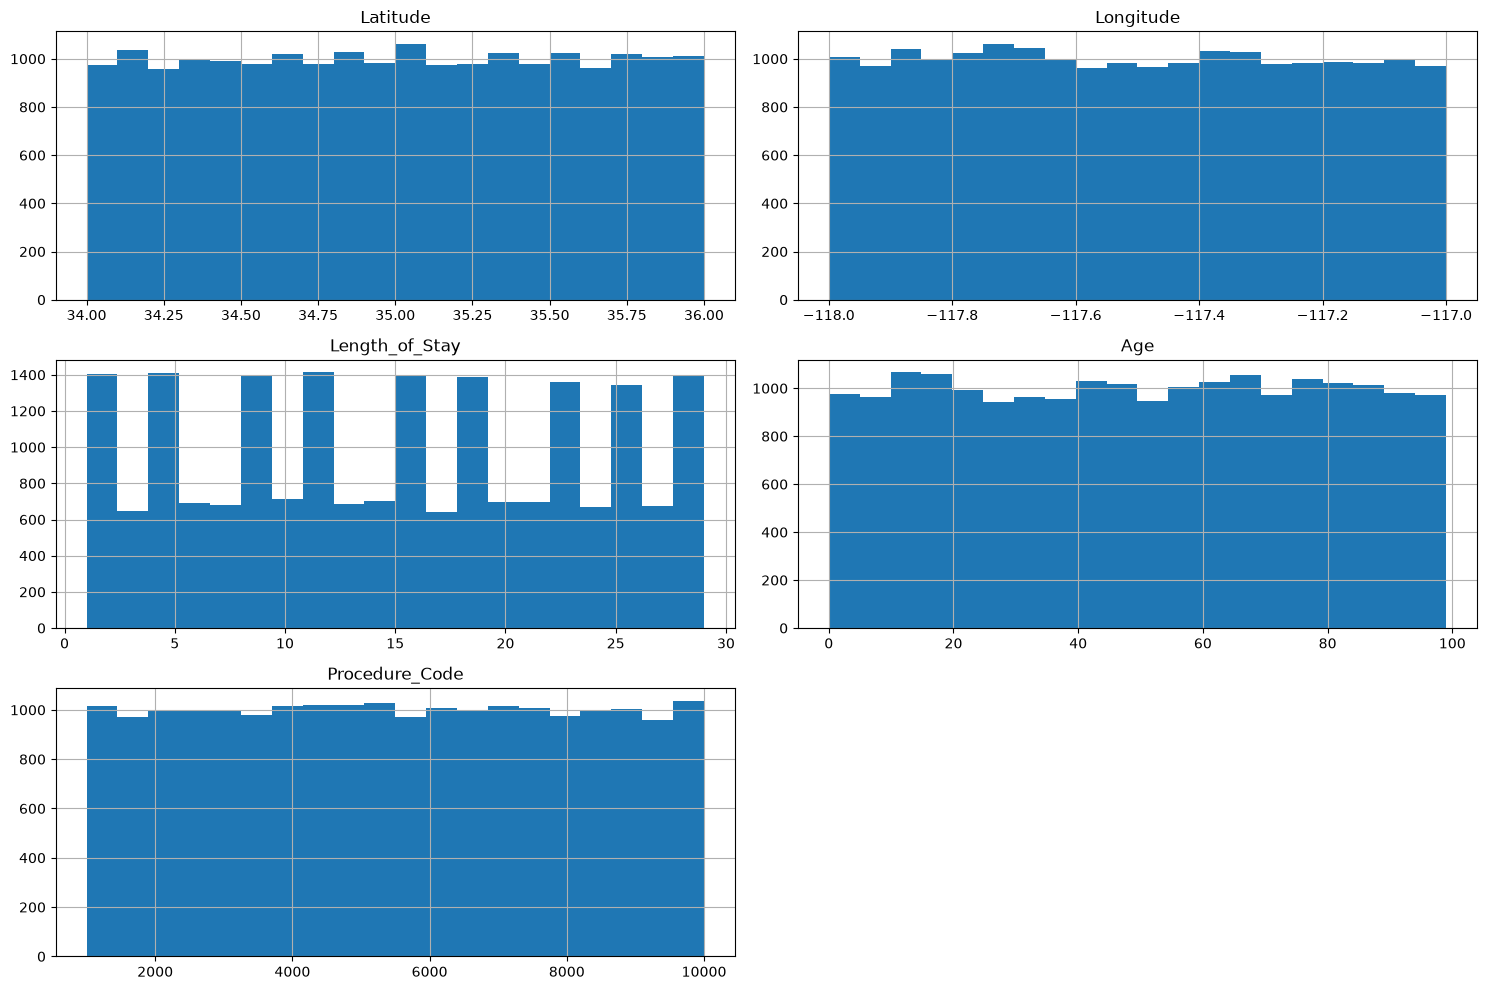

In [89]:
df[numerical_cols].hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

In [90]:
for col in categorical_cols:
    print("\n---", col, "---")
    print(df[col].value_counts().head(10))


--- PatientID ---
PatientID
624c2f33-ddee-4cec-b3af-6b066c9460ac    1
7d4fa4db-d71c-477c-b82a-1c6f87e4cc5c    1
12a1fe7d-dfa5-4722-8a1f-c9df9a591974    1
92abe1cb-7f1f-4b30-855f-9ac0a1a5366b    1
69fb0763-8a9c-46f7-8ee4-e5125802b640    1
1e6773d7-f3aa-472b-abf4-5b9d5e8c8bbf    1
f1738856-e25d-46eb-9e9a-9f83066803ee    1
ec5464a1-8773-4e8a-b013-d7625d4a2b4a    1
8d6b456e-49bc-4c58-8b3e-32c1614e73e0    1
e958c745-02bb-457d-8225-51d2e44e923a    1
Name: count, dtype: int64

--- Street ---
Street
2687 Christine Crescent Apt. 794    1
089 Hahn Fort                       1
12652 Aaron Centers                 1
9327 Bond Curve                     1
275 Harmon Trail Suite 350          1
1161 John Manor Suite 512           1
42872 Daniel Underpass              1
18028 Owens Plaza                   1
6866 Herrera Pike                   1
75305 Cynthia Lane Apt. 212         1
Name: count, dtype: int64

--- Location ---
Location
New Michael        23
West Jennifer      17
Lake Jennifer      17
Mic

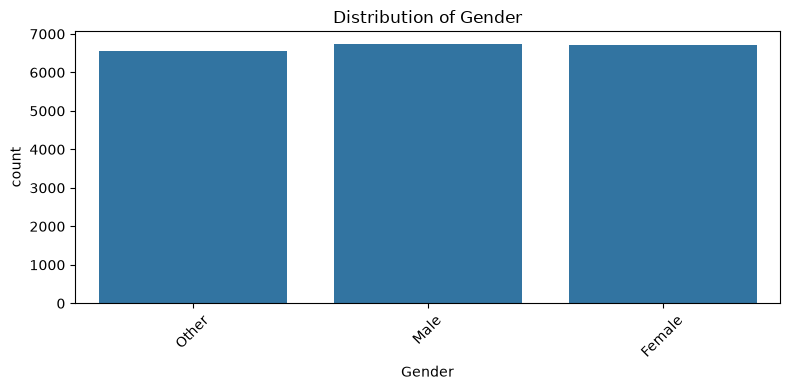

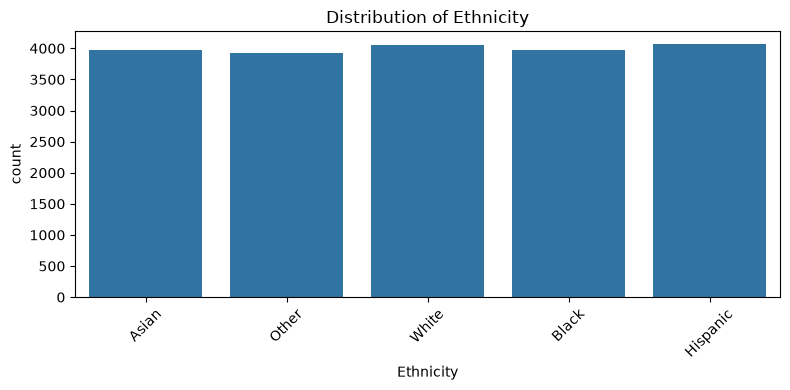

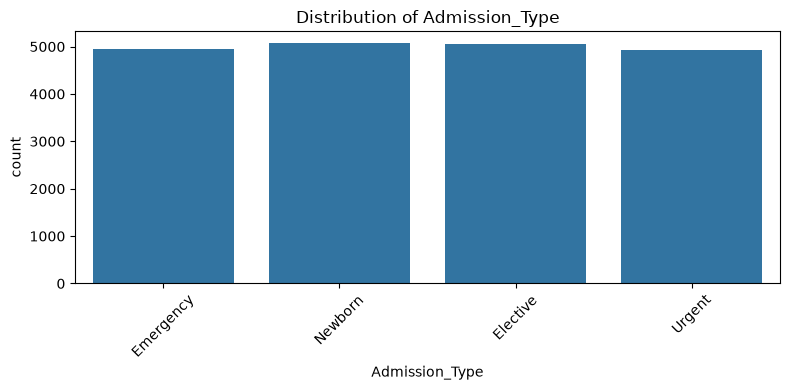

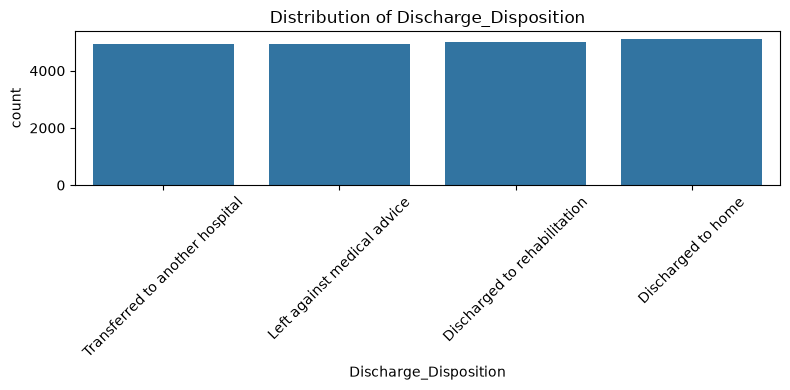

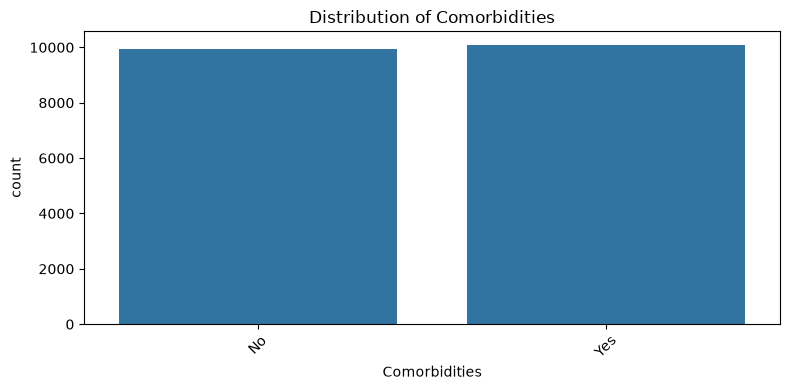

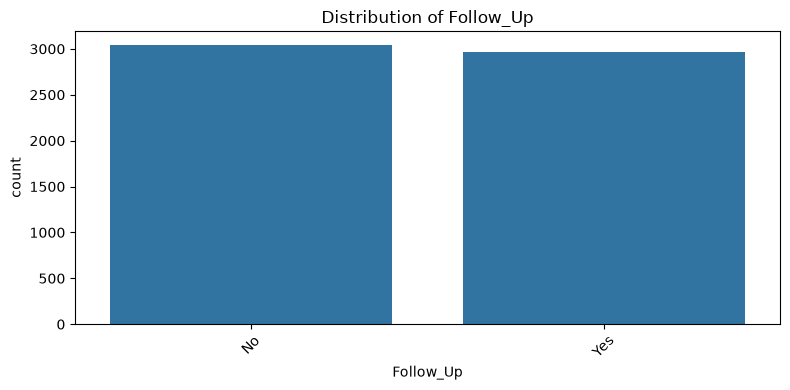

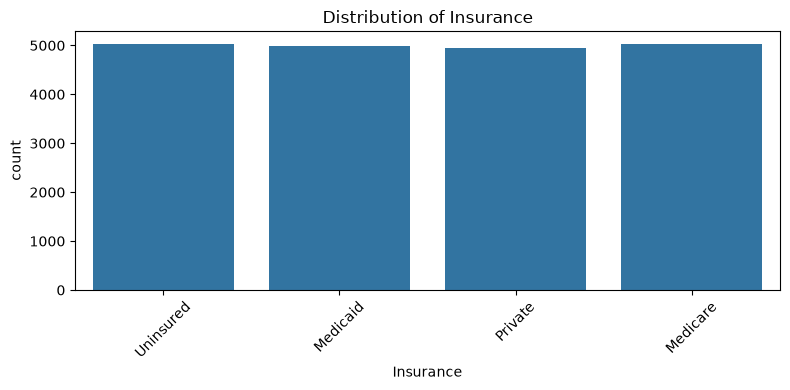

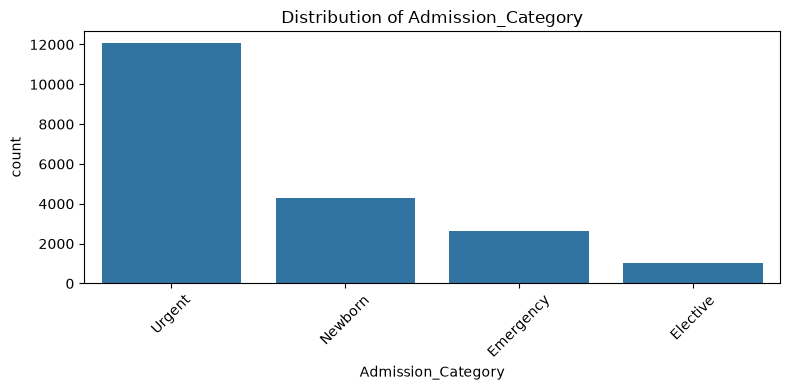

In [91]:
important_cats = [
    "Gender",
    "Ethnicity",
    "Admission_Type",
    "Discharge_Disposition",
    "Comorbidities",
    "Follow_Up",
    "Insurance",
    "Admission_Category"
]

for col in important_cats:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [92]:
numerical_cols = df.select_dtypes(include=np.number).columns
print(numerical_cols.tolist())

['Latitude', 'Longitude', 'Length_of_Stay', 'Age', 'Procedure_Code']


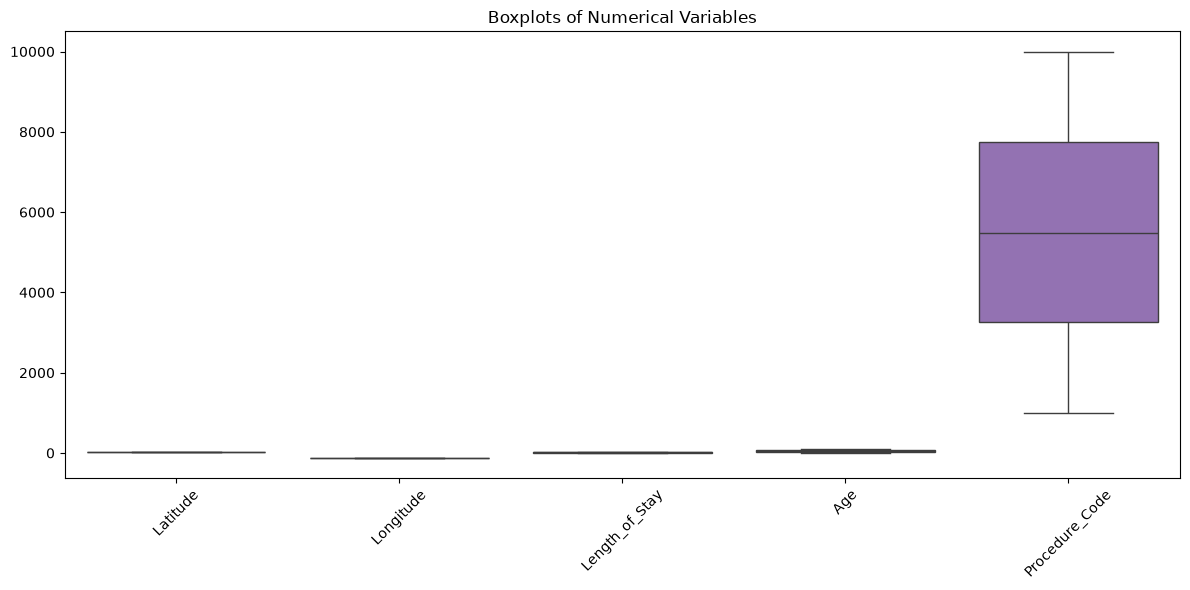

In [93]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Variables")
plt.tight_layout()
plt.show()

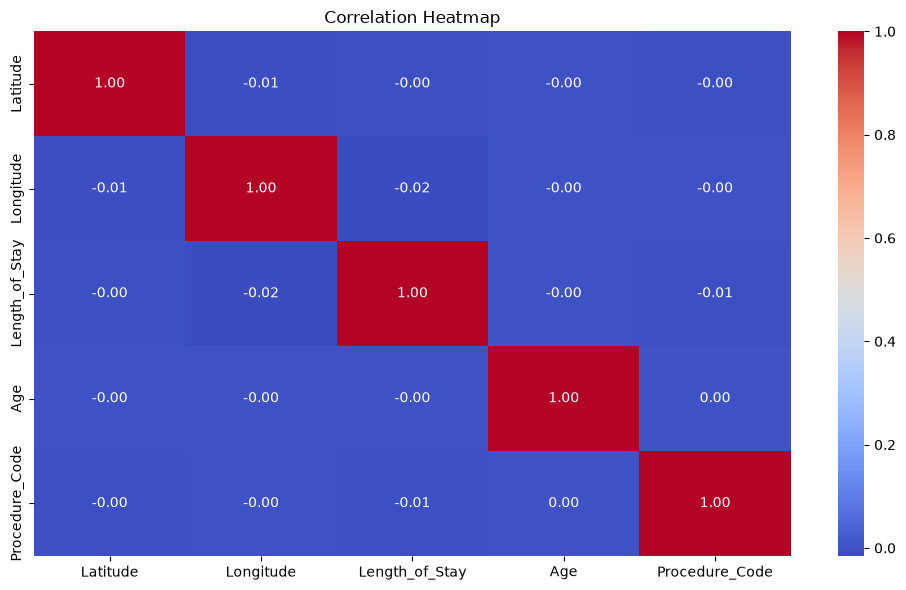

In [94]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [95]:
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"])

print(df[["Admission_Date", "Discharge_Date"]].dtypes)

Admission_Date    datetime64[us]
Discharge_Date    datetime64[us]
dtype: object


In [96]:
df["Calculated_Length_of_Stay"] = (
    df["Discharge_Date"] - df["Admission_Date"]
).dt.days

df[["Admission_Date", "Discharge_Date", "Length_of_Stay", "Calculated_Length_of_Stay"]].head(10)

,Admission_Date,Discharge_Date,Length_of_Stay,Calculated_Length_of_Stay
0,2022-10-31,2022-11-11,24,11
1,2023-05-14,2020-02-28,10,-1171
2,2021-08-27,2021-02-26,11,-182
3,2023-04-17,2024-05-02,19,381
4,2023-02-15,2023-02-18,6,3
5,2020-02-11,2023-06-23,7,1228
6,2024-03-20,2021-09-10,8,-922
7,2021-09-03,2020-02-24,11,-557
8,2021-09-30,2020-01-20,27,-619
9,2020-12-24,2020-12-20,14,-4


In [97]:
print("Mismatched rows:",
      (df["Length_of_Stay"] != df["Calculated_Length_of_Stay"]).sum())

print("\nCalculated Length of Stay:")
print(df["Calculated_Length_of_Stay"].describe())

Mismatched rows: 19992

Calculated Length of Stay:
count    20000.00000
mean        -4.76720
std        668.94932
min      -1620.00000
25%       -487.00000
50%         -6.50000
75%        478.00000
max       1609.00000
Name: Calculated_Length_of_Stay, dtype: float64


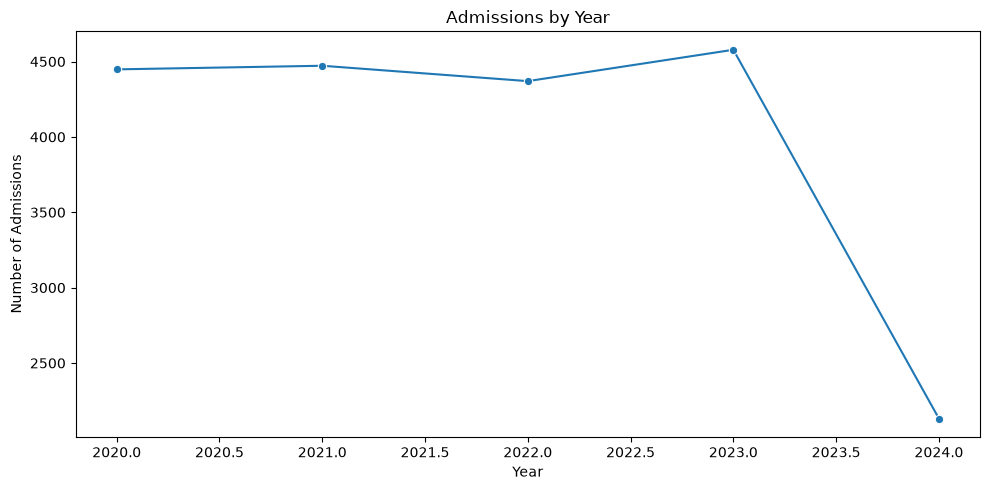

In [98]:
df["Admission_Year"] = df["Admission_Date"].dt.year

yearly_admissions = df["Admission_Year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly_admissions.index, y=yearly_admissions.values, marker="o")
plt.title("Admissions by Year")
plt.xlabel("Year")
plt.ylabel("Number of Admissions")
plt.tight_layout()
plt.show()

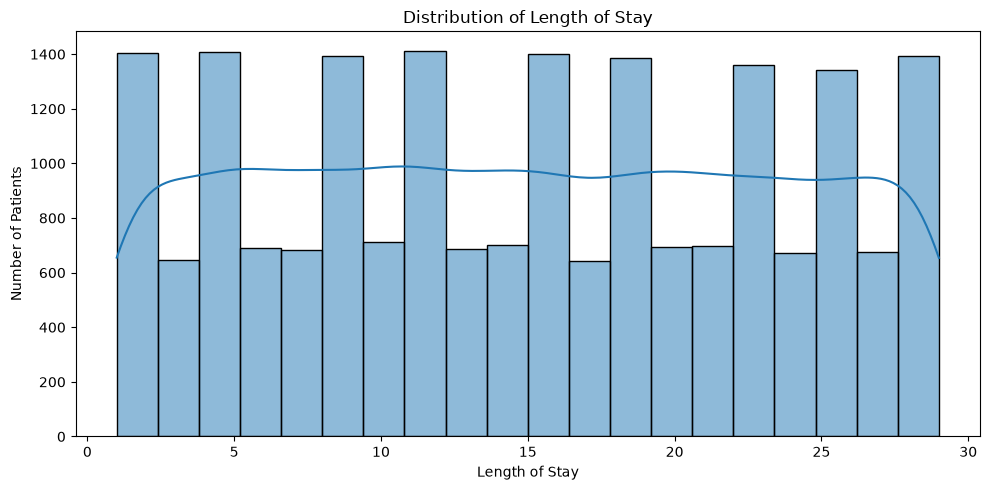

In [99]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Length_of_Stay"], bins=20, kde=True)
plt.title("Distribution of Length of Stay")
plt.xlabel("Length of Stay")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

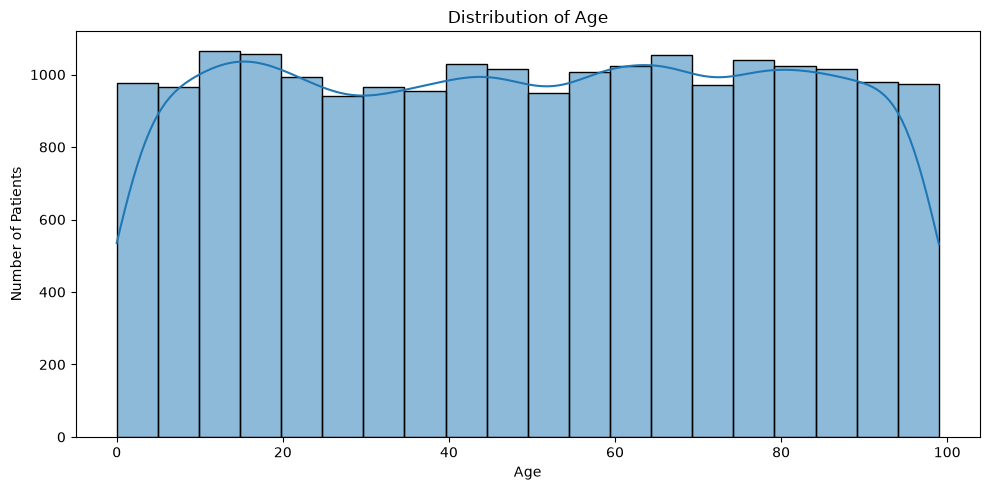

In [100]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

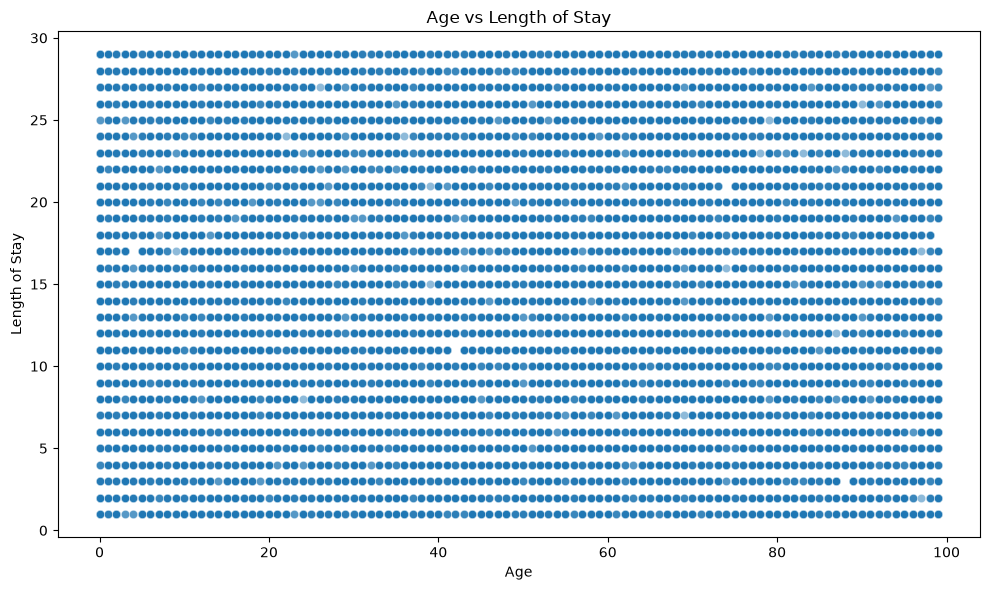

In [101]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Age", y="Length_of_Stay", alpha=0.5)
plt.title("Age vs Length of Stay")
plt.xlabel("Age")
plt.ylabel("Length of Stay")
plt.tight_layout()
plt.show()

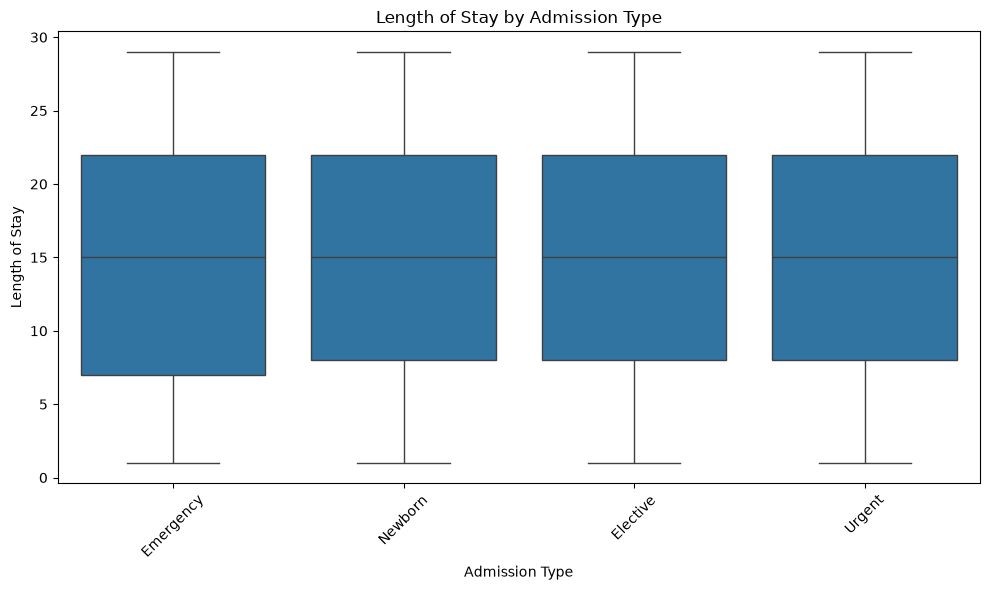

In [102]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Admission_Type", y="Length_of_Stay")
plt.title("Length of Stay by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Length of Stay")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

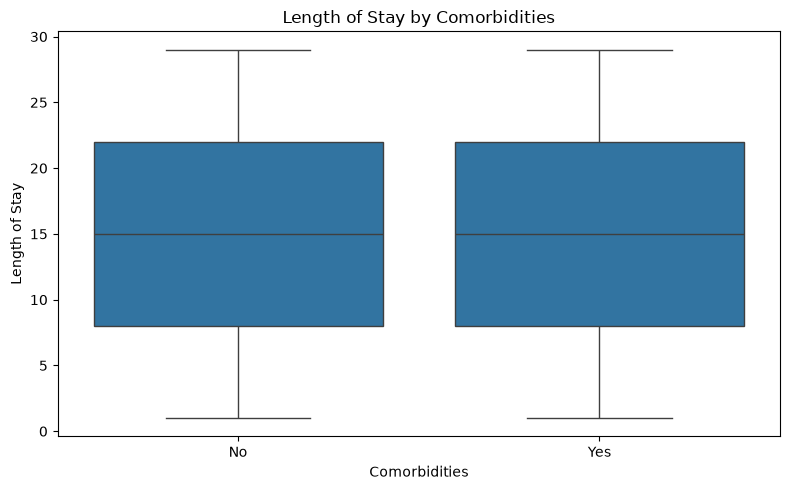

In [103]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Comorbidities", y="Length_of_Stay")
plt.title("Length of Stay by Comorbidities")
plt.xlabel("Comorbidities")
plt.ylabel("Length of Stay")
plt.tight_layout()
plt.show()

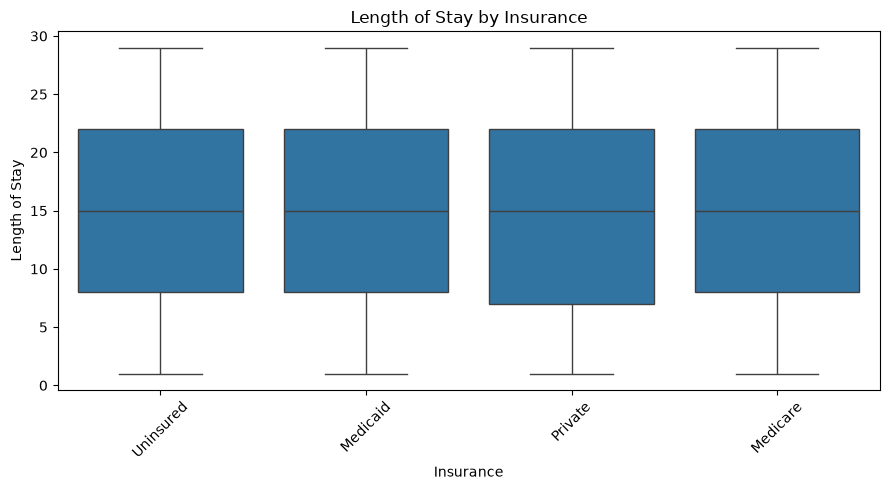

In [104]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Insurance", y="Length_of_Stay")
plt.title("Length of Stay by Insurance")
plt.xlabel("Insurance")
plt.ylabel("Length of Stay")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

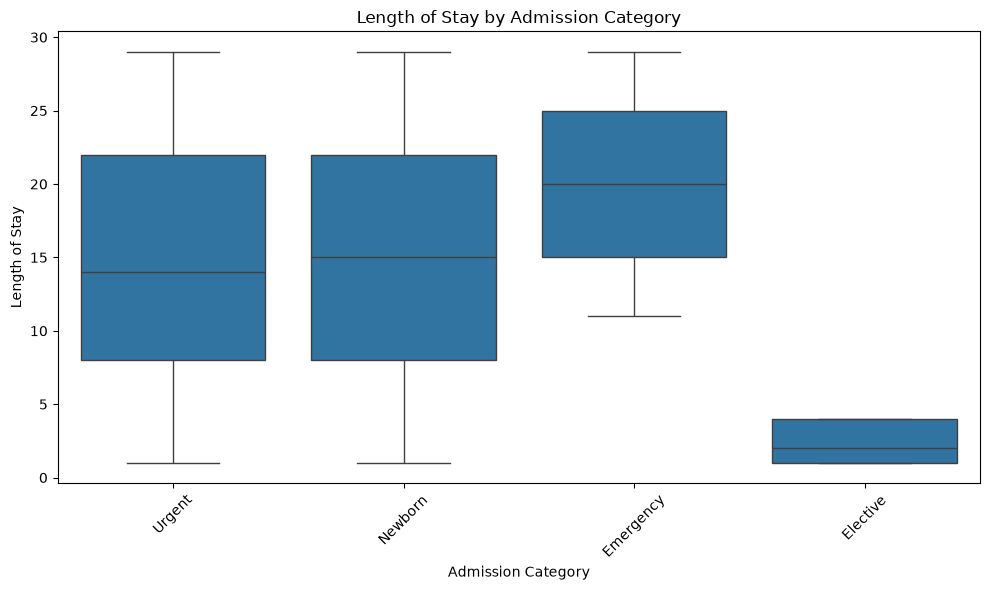

In [105]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Admission_Category", y="Length_of_Stay")
plt.title("Length of Stay by Admission Category")
plt.xlabel("Admission Category")
plt.ylabel("Length of Stay")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

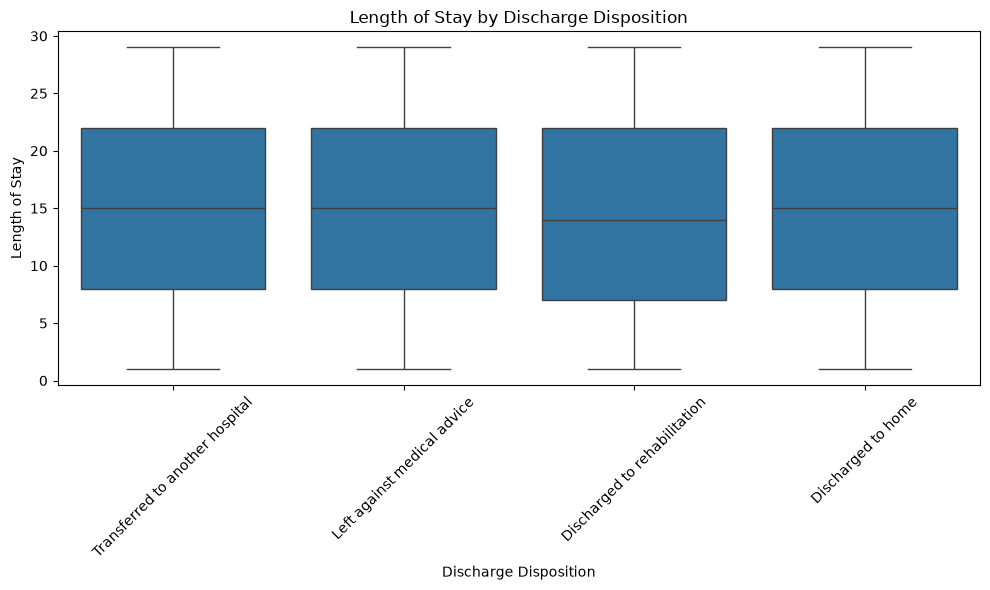

In [106]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Discharge_Disposition", y="Length_of_Stay")
plt.title("Length of Stay by Discharge Disposition")
plt.xlabel("Discharge Disposition")
plt.ylabel("Length of Stay")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

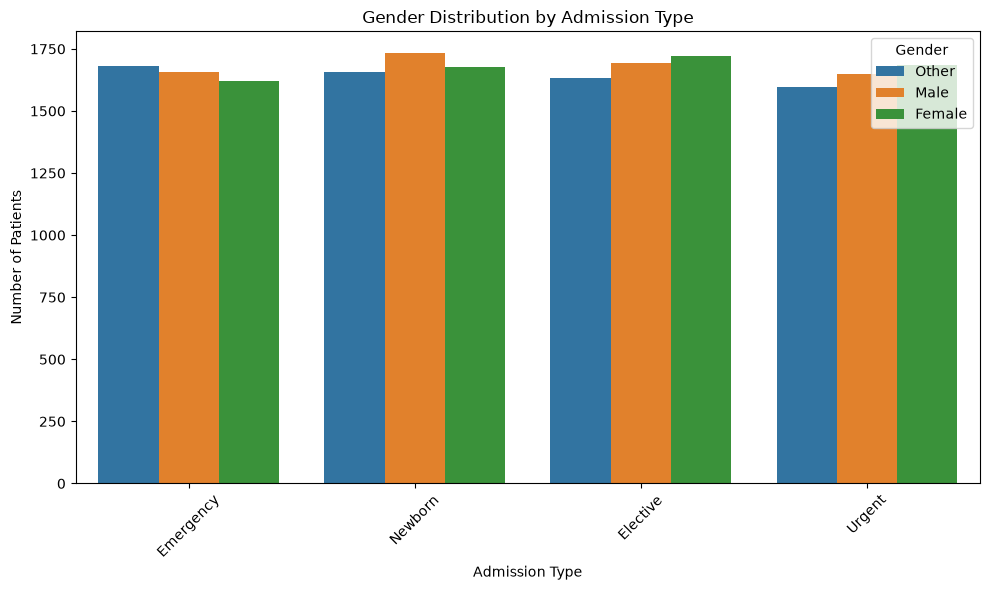

In [107]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Admission_Type", hue="Gender")
plt.title("Gender Distribution by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

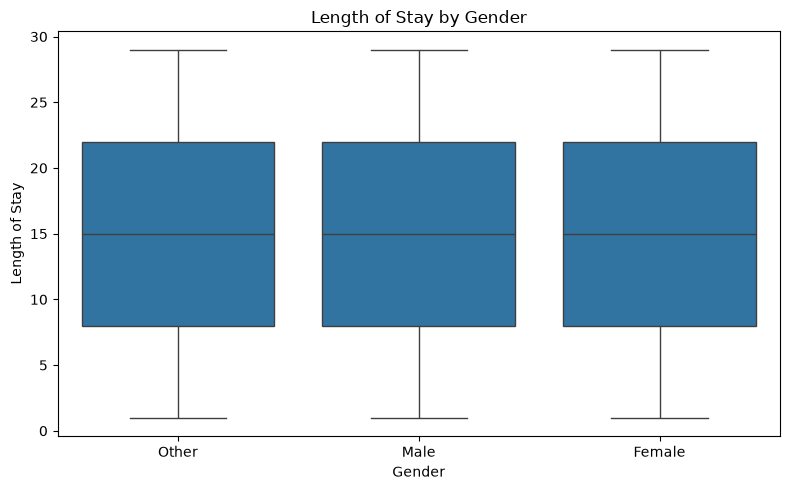

In [108]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Gender", y="Length_of_Stay")
plt.title("Length of Stay by Gender")
plt.xlabel("Gender")
plt.ylabel("Length of Stay")
plt.tight_layout()
plt.show()

In [109]:
for col in ["Gender", "Admission_Type", "Comorbidities", "Follow_Up", "Insurance", "Admission_Category"]:
    print(f"\n--- Average Length of Stay by {col} ---")
    print(df.groupby(col)["Length_of_Stay"].agg(["mean", "median", "min", "max"]).round(2))


--- Average Length of Stay by Gender ---
         mean  median  min  max
Gender                         
Female  14.92    15.0    1   29
Male    14.96    15.0    1   29
Other   14.95    15.0    1   29

--- Average Length of Stay by Admission_Type ---
                 mean  median  min  max
Admission_Type                         
Elective        14.90    15.0    1   29
Emergency       14.77    15.0    1   29
Newborn         15.00    15.0    1   29
Urgent          15.11    15.0    1   29

--- Average Length of Stay by Comorbidities ---
                mean  median  min  max
Comorbidities                         
No             15.04    15.0    1   29
Yes            14.85    15.0    1   29

--- Average Length of Stay by Follow_Up ---
            mean  median  min  max
Follow_Up                         
No         15.08    15.0    1   29
Yes        14.95    15.0    1   29

--- Average Length of Stay by Insurance ---
            mean  median  min  max
Insurance                         
Med

In [110]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_pct.round(2)
})

missing_summary = missing_summary[missing_summary["Missing_Count"] > 0].sort_values(
    "Missing_Count", ascending=False
)

missing_summary

,Missing_Count,Missing_Percentage
Follow_Up,14000,70.0
Street,12000,60.0
Location,2000,10.0
Notes,2000,10.0


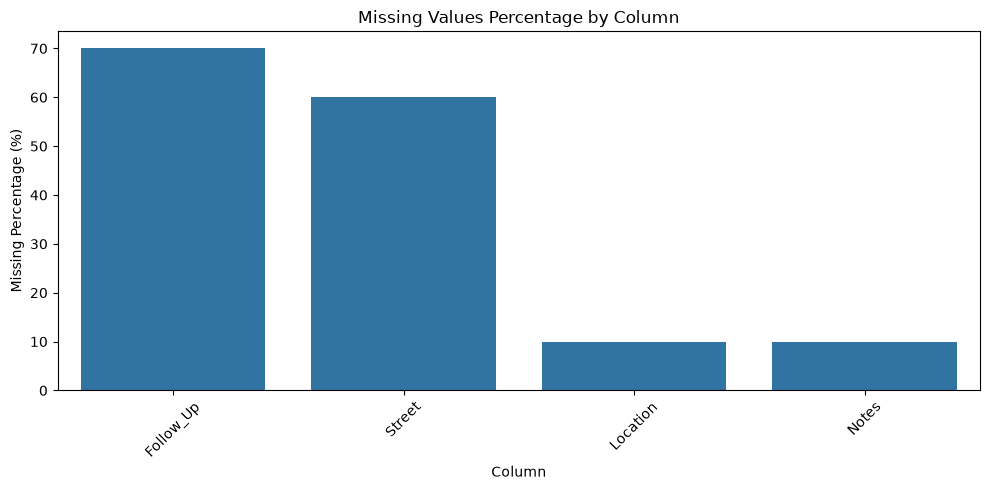

In [111]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=missing_summary.index,
    y=missing_summary["Missing_Percentage"]
)
plt.title("Missing Values Percentage by Column")
plt.xlabel("Column")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

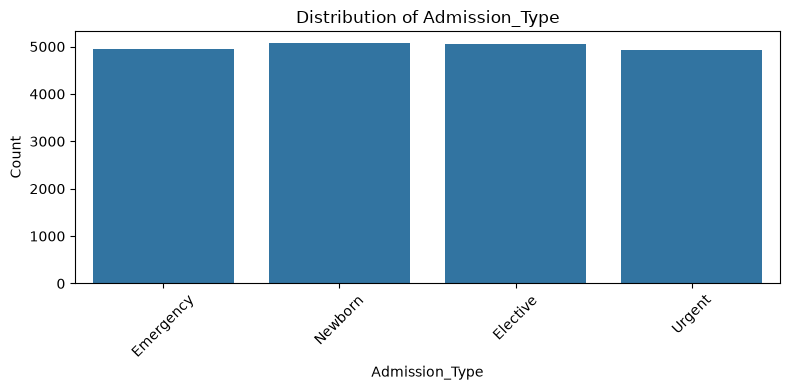

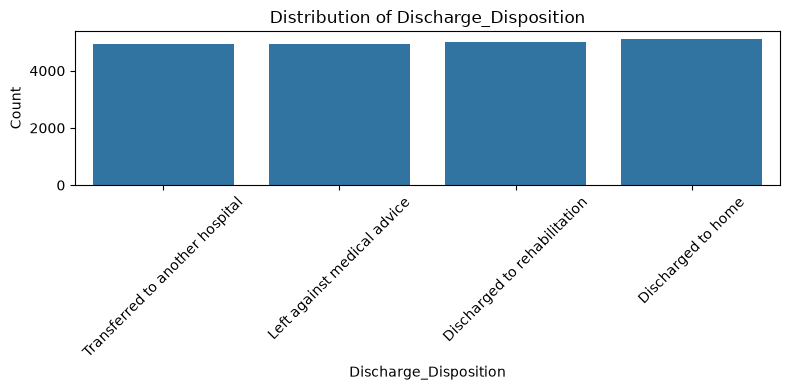

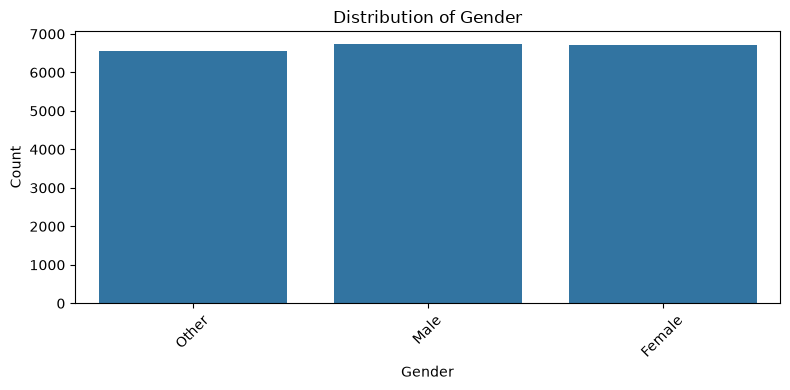

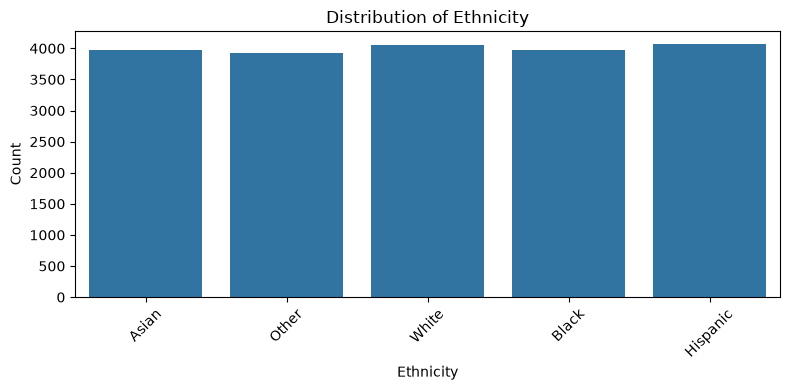

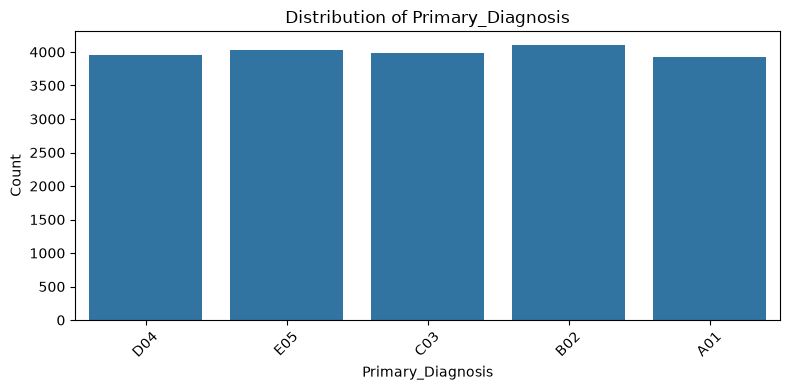

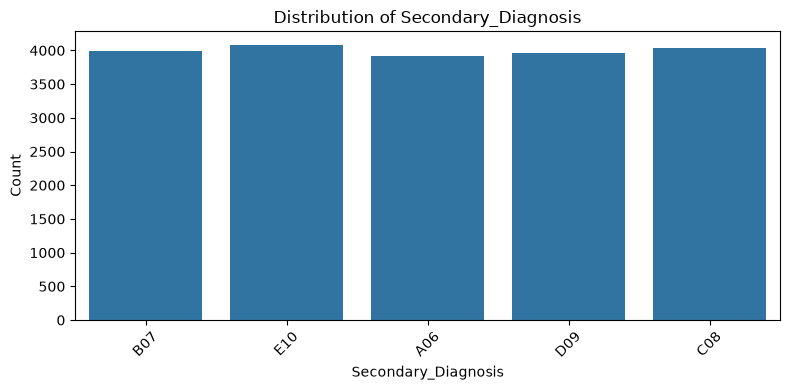

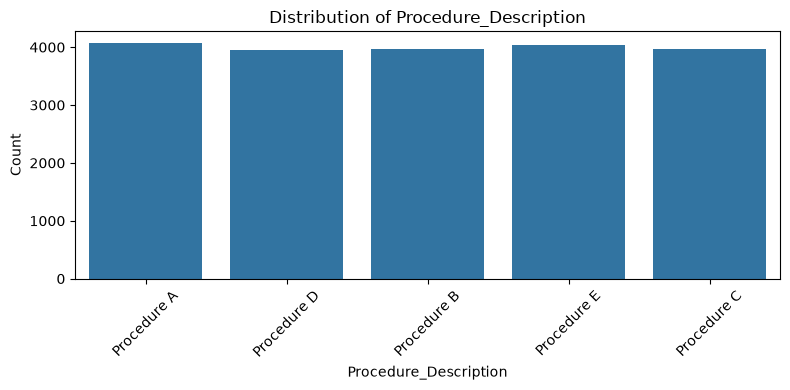

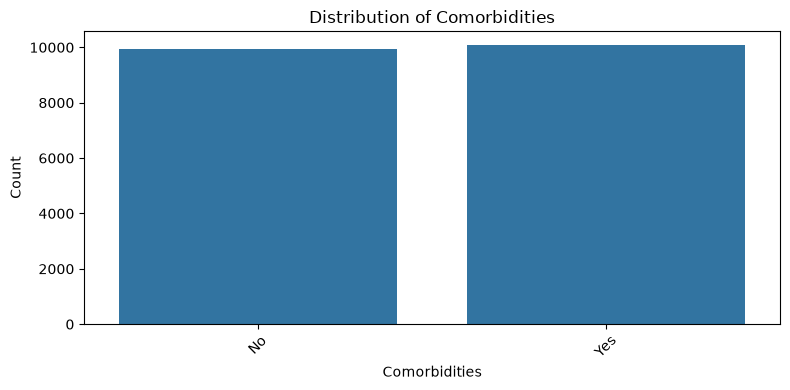

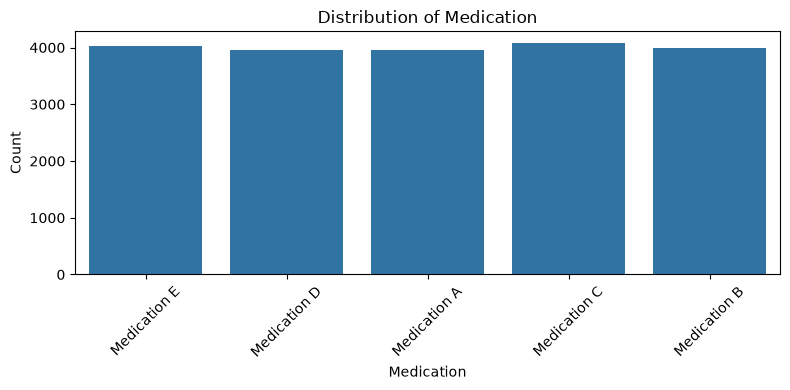

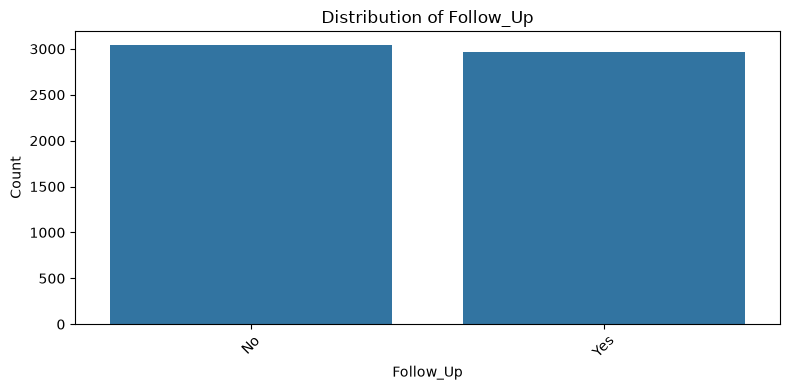

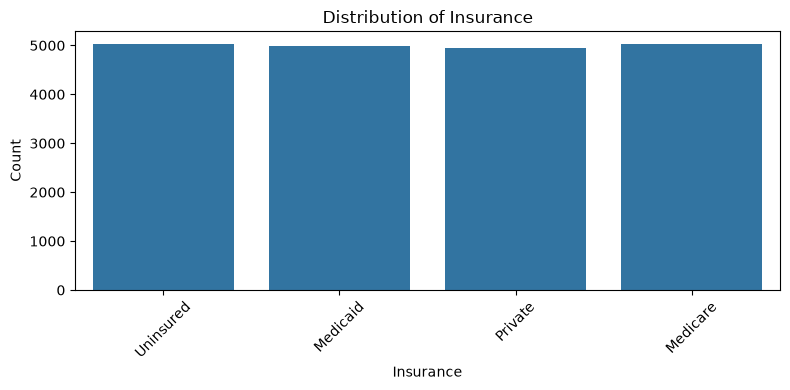

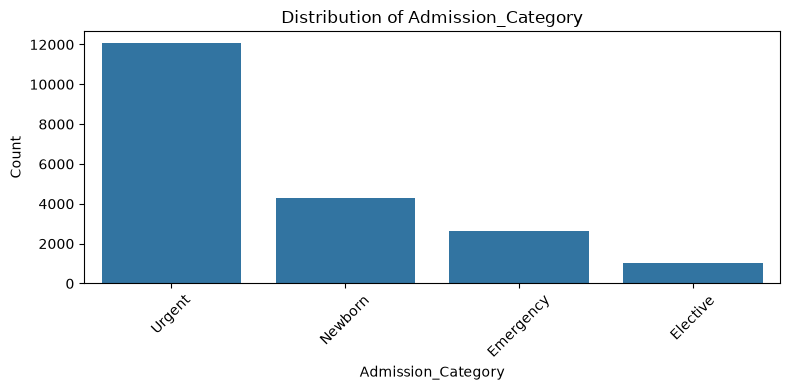

In [112]:
categorical_cols = [
    "Admission_Type",
    "Discharge_Disposition",
    "Gender",
    "Ethnicity",
    "Primary_Diagnosis",
    "Secondary_Diagnosis",
    "Procedure_Description",
    "Comorbidities",
    "Medication",
    "Follow_Up",
    "Insurance",
    "Admission_Category"
]

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

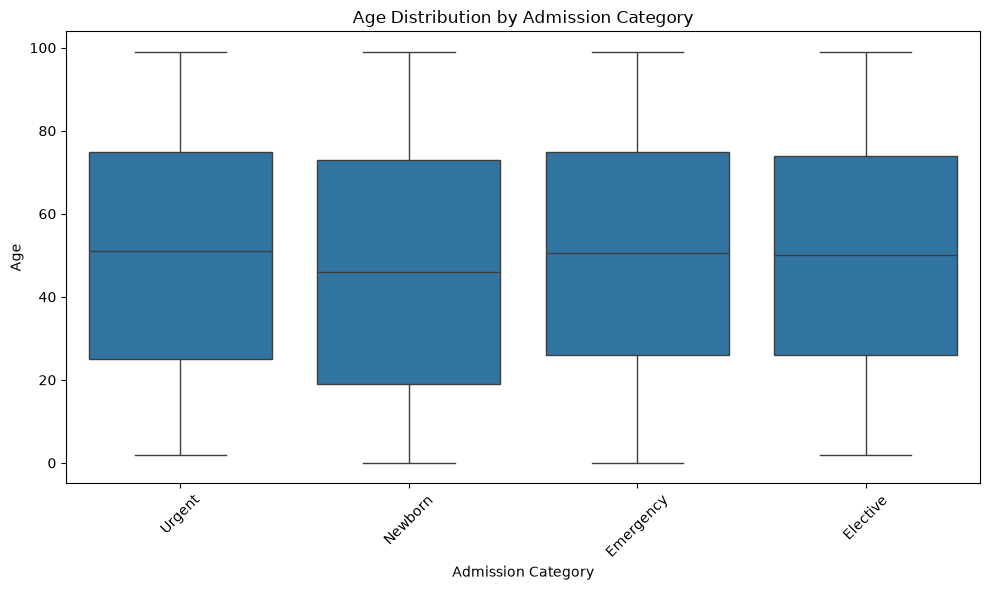

In [113]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Admission_Category", y="Age")
plt.title("Age Distribution by Admission Category")
plt.xlabel("Admission Category")
plt.ylabel("Age")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [114]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [115]:
print("Duplicate Patient IDs:", df["PatientID"].duplicated().sum())

Duplicate Patient IDs: 0


In [116]:
print("Invalid date rows:", (df["Discharge_Date"] < df["Admission_Date"]).sum())

Invalid date rows: 10073


In [117]:
invalid_dates = df[df["Discharge_Date"] < df["Admission_Date"]]

invalid_dates[["Admission_Date", "Discharge_Date", "Length_of_Stay"]].head(10)

,Admission_Date,Discharge_Date,Length_of_Stay
1,2023-05-14,2020-02-28,10
2,2021-08-27,2021-02-26,11
6,2024-03-20,2021-09-10,8
7,2021-09-03,2020-02-24,11
8,2021-09-30,2020-01-20,27
9,2020-12-24,2020-12-20,14
10,2024-05-14,2021-08-11,13
12,2024-03-19,2023-03-25,12
16,2021-02-13,2020-05-17,28
17,2022-02-15,2021-02-03,7


In [118]:
print(
    "Rows where Length_of_Stay matches date difference:",
    (df["Length_of_Stay"] == (df["Discharge_Date"] - df["Admission_Date"]).dt.days).sum()
)

print(
    "Rows where Length_of_Stay does NOT match:",
    (df["Length_of_Stay"] != (df["Discharge_Date"] - df["Admission_Date"]).dt.days).sum()
)

Rows where Length_of_Stay matches date difference: 8
Rows where Length_of_Stay does NOT match: 19992


In [119]:
print("Minimum Age:", df["Age"].min())
print("Maximum Age:", df["Age"].max())

print("\nAge values outside 0-100:")
print(df[(df["Age"] < 0) | (df["Age"] > 100)][["Age"]].head(20))

Minimum Age: 0
Maximum Age: 99

Age values outside 0-100:
Empty DataFrame
Columns: [Age]
Index: []


In [120]:
print("Minimum Length of Stay:", df["Length_of_Stay"].min())
print("Maximum Length of Stay:", df["Length_of_Stay"].max())

print("\nInvalid Length of Stay values:")
print(df[(df["Length_of_Stay"] <= 0) | (df["Length_of_Stay"] > 365)][["Length_of_Stay"]].head(20))

Minimum Length of Stay: 1
Maximum Length of Stay: 29

Invalid Length of Stay values:
Empty DataFrame
Columns: [Length_of_Stay]
Index: []


In [121]:
print(df[numerical_cols].isnull().sum())

Latitude          0
Longitude         0
Length_of_Stay    0
Age               0
Procedure_Code    0
dtype: int64


In [122]:
print("Minimum Procedure Code:", df["Procedure_Code"].min())
print("Maximum Procedure Code:", df["Procedure_Code"].max())
print("\nUnique Procedure Codes:", df["Procedure_Code"].nunique())

Minimum Procedure Code: 1000
Maximum Procedure Code: 9998

Unique Procedure Codes: 8010


In [123]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    print(f"{col}: {outliers} outliers")

Latitude: 0 outliers
Longitude: 0 outliers
Length_of_Stay: 0 outliers
Age: 0 outliers
Procedure_Code: 0 outliers


In [124]:
categorical_missing = df[categorical_cols].isnull().sum()
categorical_missing = categorical_missing[categorical_missing > 0].sort_values(ascending=False)

print(categorical_missing)

Follow_Up    14000
dtype: int64


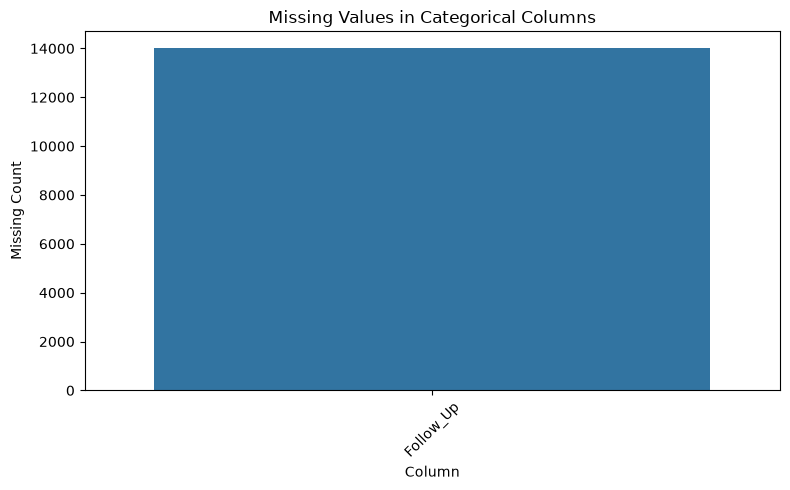

In [125]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=categorical_missing.index,
    y=categorical_missing.values
)
plt.title("Missing Values in Categorical Columns")
plt.xlabel("Column")
plt.ylabel("Missing Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [126]:
pd.crosstab(df["Admission_Category"], df["Admission_Type"])

Admission_Type,Elective,Emergency,Newborn,Urgent
Admission_Category,,,,
Elective,255,276,261,231
Emergency,673,638,660,649
Newborn,1032,1075,1092,1101
Urgent,3085,2968,3055,2949


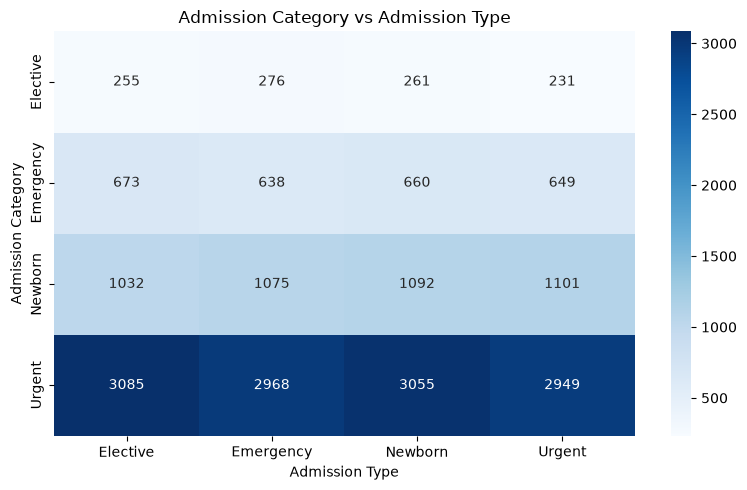

In [127]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    pd.crosstab(df["Admission_Category"], df["Admission_Type"]),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Admission Category vs Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Admission Category")
plt.tight_layout()
plt.show()

In [128]:
print(df["Admission_Category"].value_counts())

Admission_Category
Urgent       12057
Newborn       4300
Emergency     2620
Elective      1023
Name: count, dtype: int64


In [129]:
print(
    (df["Admission_Category"].value_counts(normalize=True) * 100).round(2)
)

Admission_Category
Urgent       60.28
Newborn      21.50
Emergency    13.10
Elective      5.12
Name: proportion, dtype: float64


In [130]:
print(
    df.groupby("Admission_Category")["Length_of_Stay"]
      .agg(["mean", "median", "min", "max"])
      .round(2)
)

                     mean  median  min  max
Admission_Category                         
Elective             2.47     2.0    1    4
Emergency           19.94    20.0   11   29
Newborn             14.92    15.0    1   29
Urgent              14.93    14.0    1   29


In [131]:
df["Admission_Month"] = df["Admission_Date"].dt.month

monthly_admissions = df["Admission_Month"].value_counts().sort_index()

print(monthly_admissions)

Admission_Month
1     1883
2     1700
3     1966
4     1758
5     1940
6     1794
7     1563
8     1498
9     1419
10    1509
11    1488
12    1482
Name: count, dtype: int64


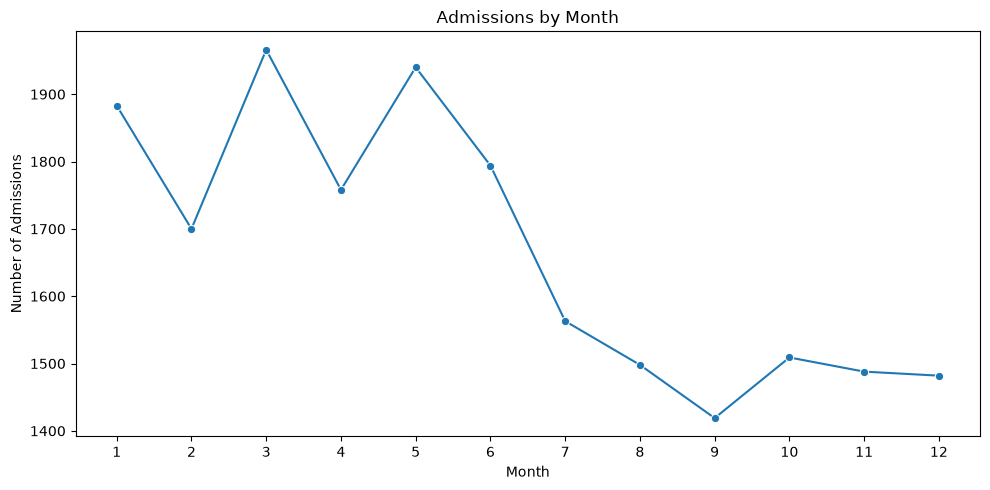

In [132]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=monthly_admissions.index,
    y=monthly_admissions.values,
    marker="o"
)

plt.title("Admissions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [133]:
gender_admissions = df["Gender"].value_counts()

gender_admissions

Gender
Male      6731
Female    6701
Other     6568
Name: count, dtype: int64

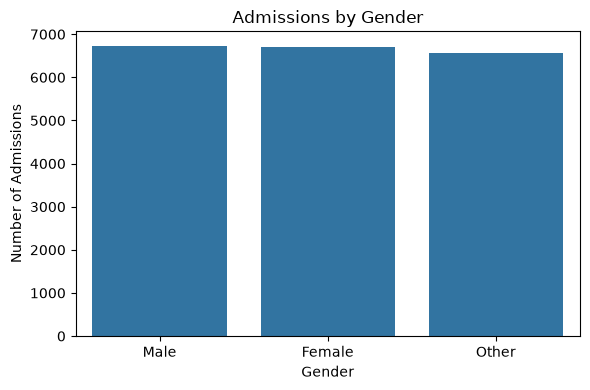

In [134]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=gender_admissions.index,
    y=gender_admissions.values
)

plt.title("Admissions by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Admissions")
plt.tight_layout()
plt.show()

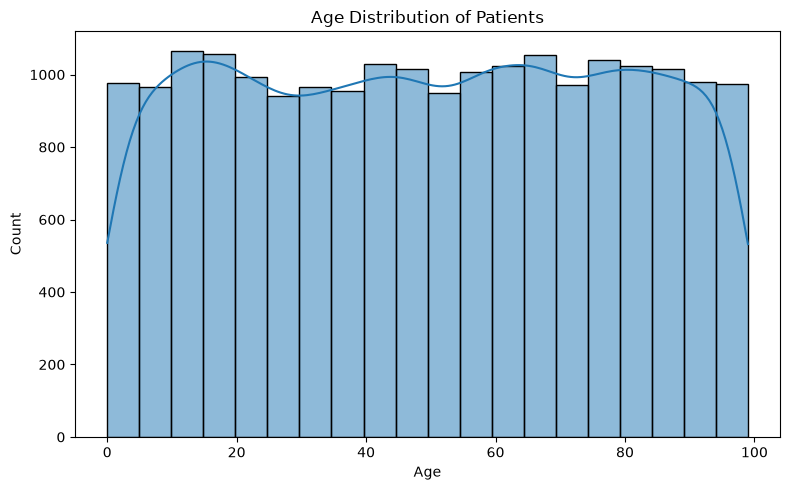

In [135]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

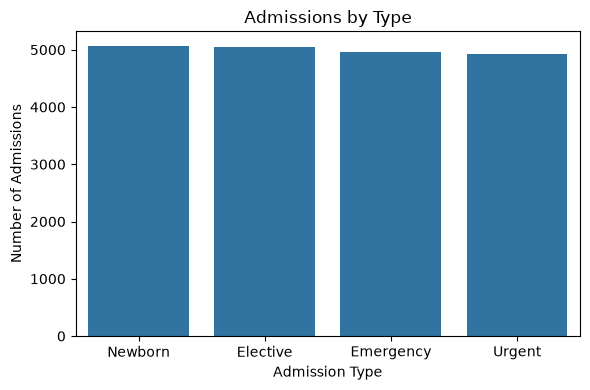

In [136]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x="Admission_Type",
    data=df,
    order=df["Admission_Type"].value_counts().index
)

plt.title("Admissions by Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Admissions")
plt.tight_layout()
plt.show()

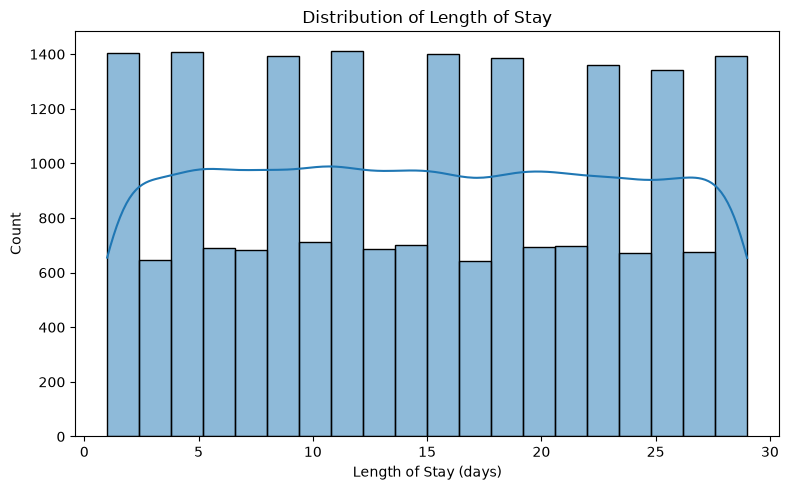

In [137]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Length_of_Stay"], bins=20, kde=True)

plt.title("Distribution of Length of Stay")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

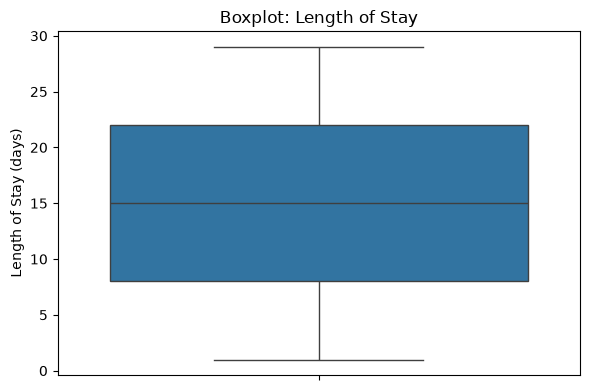

In [138]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["Length_of_Stay"])
plt.title("Boxplot: Length of Stay")
plt.ylabel("Length of Stay (days)")
plt.tight_layout()
plt.show()

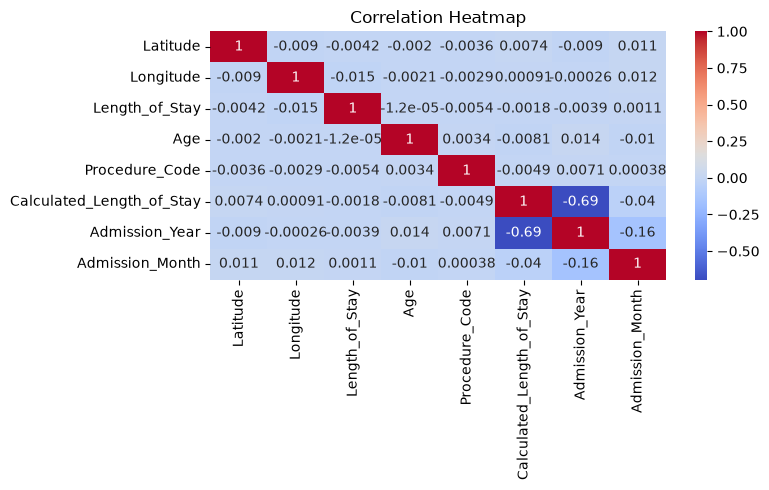

In [139]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [140]:
df.describe(include="all")

,PatientID,Street,Location,Latitude,Longitude,Admission_Type,Discharge_Disposition,Admission_Date,Discharge_Date,Length_of_Stay,...,Medication,Follow_Up,Insurance,Notes,Doctor_Comments,Medication_Details,Admission_Category,Calculated_Length_of_Stay,Admission_Year,Admission_Month
count,20000,8000,18000,20000.000000,20000.000000,20000,20000,20000,20000,20000.00000,...,20000,6000,20000,18000,20000,20000,20000,20000.00000,20000.000000,20000.00000
unique,20000,8000,12301,NaN,NaN,4,4,NaN,NaN,NaN,...,5,2,4,18000,20000,20000,4,NaN,NaN,NaN
top,624c2f33-ddee-4cec-b3af-6b066c9460ac,2687 Christine Crescent Apt. 794,New Michael,NaN,NaN,Newborn,Discharged to home,NaN,NaN,NaN,...,Medication C,No,Uninsured,Building not including find defense even task ...,Camera full society example. Experience truth ...,Concern view administration take to so treatme...,Urgent,NaN,NaN,NaN
freq,1,1,23,NaN,NaN,5068,5122,NaN,NaN,NaN,...,4081,3039,5036,1,1,1,12057,NaN,NaN,NaN
mean,NaN,NaN,NaN,35.002070,-117.503118,NaN,NaN,2022-03-30 21:26:55.680000,2022-03-26 03:02:09.600000,14.94525,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.76720,2021.773700,6.18075
min,NaN,NaN,NaN,34.000023,-117.999983,NaN,NaN,2020-01-01 00:00:00,2020-01-01 00:00:00,1.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1620.00000,2020.000000,1.00000
25%,NaN,NaN,NaN,34.504021,-117.752416,NaN,NaN,2021-02-14 00:00:00,2021-02-10 00:00:00,8.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-487.00000,2021.000000,3.00000
50%,NaN,NaN,NaN,35.003402,-117.504299,NaN,NaN,2022-04-02 00:00:00,2022-03-27 00:00:00,15.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.50000,2022.000000,6.00000
75%,NaN,NaN,NaN,35.502208,-117.253263,NaN,NaN,2023-05-15 00:00:00,2023-05-07 00:00:00,22.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,478.00000,2023.000000,9.00000
max,NaN,NaN,NaN,35.999802,-117.000028,NaN,NaN,2024-06-21 00:00:00,2024-06-21 00:00:00,29.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1609.00000,2024.000000,12.00000


In [141]:
print("=== EDA Summary ===")
print(f"Total Records: {len(df)}")
print(f"Missing Values:\n{df.isnull().sum().sum()} total")
print(f"\nGender Split:\n{df['Gender'].value_counts()}")
print(f"\nAvg Length of Stay: {df['Length_of_Stay'].mean():.2f} days")
print(f"\nMost Common Admission Category:\n{df['Admission_Category'].value_counts().idxmax()}")

=== EDA Summary ===
Total Records: 20000
Missing Values:
30000 total

Gender Split:
Gender
Male      6731
Female    6701
Other     6568
Name: count, dtype: int64

Avg Length of Stay: 14.95 days

Most Common Admission Category:
Urgent


In [142]:
missing_cols = ["Street", "Location", "Follow_Up", "Notes"]
(df[missing_cols].isnull().sum() / len(df) * 100).round(2)

Street       60.0
Location     10.0
Follow_Up    70.0
Notes        10.0
dtype: float64

In [143]:
df["Follow_Up"].value_counts(dropna=False)

Follow_Up
NaN    14000
No      3039
Yes     2961
Name: count, dtype: int64

In [144]:
df["Notes"] = df["Notes"].fillna("No Notes")
df["Street"] = df["Street"].fillna("Unknown")

In [145]:
df["Follow_Up"] = df["Follow_Up"].fillna("Unknown")

In [146]:
df["Location"] = df["Location"].fillna("Unknown")

In [147]:
df.isnull().sum()

PatientID                    0
Street                       0
Location                     0
Latitude                     0
Longitude                    0
Admission_Type               0
Discharge_Disposition        0
Admission_Date               0
Discharge_Date               0
Length_of_Stay               0
Age                          0
Gender                       0
Ethnicity                    0
Primary_Diagnosis            0
Secondary_Diagnosis          0
Procedure_Code               0
Procedure_Description        0
Comorbidities                0
Medication                   0
Follow_Up                    0
Insurance                    0
Notes                        0
Doctor_Comments              0
Medication_Details           0
Admission_Category           0
Calculated_Length_of_Stay    0
Admission_Year               0
Admission_Month              0
dtype: int64